In [1]:
import sys
sys.path.append('../../utils')
from functions import * 

In [2]:
from importlib import reload
import sys
import scipy as sp
from scipy.special import expit, logit

import matplotlib.pyplot as plt 

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [3]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

import  load_cluster_data
reload (load_cluster_data)

from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Some utility functions 


In [4]:
# write function that takes in Cluster name 
def check_SS_cluster(cluster_name):
    
    # this cluster can also be used to label intron clusters as exon inclusion/exclusion event 
    juncs_c = junc_info[junc_info["Cluster"] == cluster_name]
    
    # keep only rows where either start or end appear twice
    s = np.array(juncs_c[juncs_c.duplicated(subset=['start'])].start.unique())
    e = np.array(juncs_c[juncs_c.duplicated(subset=['end'])].end.unique())
    juncs_c = juncs_c[(juncs_c["start"].isin(s)) | (juncs_c["end"].isin(e))]

    # if num rows in juncs_c is 3 then return cluster name 
    if len(juncs_c == 3):
        # confirm cluster has non zero counts in both cell types 
        num_celltypes = len(final_data[final_data.Cluster == cluster_name].cell_type.unique())
        if num_celltypes > 1:
            # confirm that each junction has non zero counts in both cell types
            counts_juncs = final_data[final_data.Cluster == cluster_name].junction_id.value_counts()
            counts_juncs = counts_juncs[counts_juncs > 1]
            num_cells=len(counts_juncs.index.unique())
            if num_cells == 3:
                return cluster_name
    else:
        pass

In [5]:
def simulate_junc_counts(cluster_counts, junc_info, cell_types=None, psi_prior_shape1=0.5, psi_prior_shape2=0.5):
    
    """Simulate junc counts while keeping the cluster counts of observed data. 
    
    Args: 
        cluster_counts: scipy coo_matrix. 
        cell_types: pandas Categorical series of pre-defined cell types to use for simulations 
        psi_prior_shape1: float.
        psi_prior_shape2: float.
    Returns:
        sim_junc_counts: scipy coo_matrix. 
        cell_type_labels: numpy array of cell type labels. 
        cell_type_psi: numpy array of cell type specific PSI values.
    """
    
    N, P = cluster_counts.shape  # number of cells, number of junctions
     
    # use real cell types labels to represent intron clusters being higher/lower in specific cell types 
    print("Using pre-defined cell types!")
    cell_type_labels = cell_types.cat.codes.to_numpy()
    K = len(cell_types.cat.categories)  # number of cell types
    
    print(N, P, K, len(cell_types))
    
    # number of intron clusters 
    num_clusters = len(junc_info.Cluster.unique())

    # label clusters as positive or negative by sampling 
    cluster_labels = np.random.choice([0, 1], size=num_clusters)

    # make a mapping of Cluster ID to cluster_labels
    cluster_labels_dict = dict(zip(junc_info.Cluster.unique(), cluster_labels))

    # initiate empty dataframe cell_type_psi_df to which we will append the simulated PSI values for each junction in each cell type
    cell_type_psi_df = pd.DataFrame()

    for clust in tqdm(junc_info.Cluster.unique()):
        clust_label = cluster_labels_dict[clust]
        # get cluster label
        # get junctions in cluster and order them by start and end 
        juncs_c = junc_info[junc_info["Cluster"] == clust]
        # order juncs_c by start and end
        juncs_c = juncs_c.sort_values(by=['start', 'end'])
        # assign J1, J2, and J3 to junctions where J1+J2 correspond to exon inclusion and J3 corresponds to exon skipping
        juncs_c["junction"] = ["J1", "J3", "J2"] 
        num_juncs = len(juncs_c)    
        if clust_label == 0: 
            # sample PSI values for each junction in each cell type via pre-defined beta distributions
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob 
            probs[1,] = probs[1,1]
            probs[0,] = (1-probs[1,1])/2
            probs[2,] = (1-probs[1,1])/2
            # convert probs to dataframe 
            probs_df = pd.DataFrame(probs.numpy())
            # add junction_id_index column to probs_df
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "negative"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # appent probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])
        elif clust_label == 1:
            probs = torch.distributions.beta.Beta(psi_prior_shape1, psi_prior_shape2).sample([num_juncs, K]) 
            # get J3 prob
            J3_prob = probs[1,]
            probs[0,] = (1-J3_prob)/2
            probs[2,] = (1-J3_prob)/2
            probs_df = pd.DataFrame(probs.numpy())
            probs_df["new_junction_id_index"] = juncs_c["new_junction_id_index"].values
            probs_df["sample_label"] = "positive"
            probs_df["Cluster"] = juncs_c["Cluster"].values[0]
            # use pd.concat to append probs_df to cell_type_psi_df
            cell_type_psi_df = pd.concat([cell_type_psi_df, probs_df])

    cell_type_psi_df = cell_type_psi_df.sort_values(by=['new_junction_id_index'])
    cell_type_psi = torch.tensor(cell_type_psi_df[[0,1]].to_numpy()) #should specify K columns insted of "0,1"
    print("Done simulating PSI!")

    # use real cluster counts to simulate junc counts with binomial distribution
    sim_junc_counts = cluster_counts.copy() 
    sim_junc_counts.data = torch.distributions.binomial.Binomial( 
         total_count=torch.tensor(cluster_counts.data), 
         probs=cell_type_psi[
             cluster_counts.col, # junction index
             cell_type_labels[cluster_counts.row] # cell index 
         ]
    ).sample().numpy()
    
    print("Done simulating junc counts!")
    
    return sim_junc_counts, cell_type_labels, cell_type_psi, cell_type_psi_df

In [6]:
def quick_clust_plot(clust, simple_data):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())
    sample_label = simple_data_junc.sample_label.unique()[0]
    plt.figuresize=(6, 6)
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    plt.title(sample_label + " label for cluster:" + str(clust), fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)", fontsize=20)
    plt.ylabel("Cell Type Group", fontsize=20)
    # increase x and y tick label size to 14
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.show()

In [7]:
def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == junc_index].junction_id.values[0]
    
    # implement utility to visualize full beta distributions for each junction in each cell type
    # using ALPHA_f and PI_f 

    # get data for just junc_index 
    junc_dat = juncs_probs_df[juncs_probs_df.new_junction_id_index == junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [8]:
# use sim_dat to get cluster level PSI for each cluster using J1+J2/J3 
def get_cluster_PSI(cluster, sim_data, junc_info):
    # cell clust counts 
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]

    # junction label info (J1, J2, J3)
    clust_dat = junc_info[junc_info["Cluster"] == cluster]
    clust_dat.sort_values(by = ["start", "end"], inplace = True)
    clust_dat["junc_label"] = ["J1", "J3", "J2"]
    clust_dat = clust_dat[["Cluster", "junc_label", "new_junction_id_index"]]
    # rename new_junction_id_index column to junction_id_index 
    clust_dat.rename(columns = {"new_junction_id_index": "junction_id_index"}, inplace = True)
    clust_only_counts = sim_data[sim_data["Cluster"] == cluster]
    #merge clust_dat with clust_only_counts 
    clust_only_counts = clust_only_counts.merge(clust_dat, on = ["Cluster", "junction_id_index"])
    clust_only_counts = clust_only_counts[["cell_id_index", "Cluster", "junction_id_index", "junc_count", "cluster_count", "junc_label"]]
    clust_only_counts.sort_values(by = ["cell_id_index", "junction_id_index"], inplace = True)
    
    clust_only_counts_mat = clust_only_counts.pivot(index = "junction_id_index", columns = "cell_id_index", values = "junc_count")
    cols_names = list(clust_only_counts_mat)
    clust_only_counts_mat["junc_label"] = clust_only_counts[["junction_id_index", "junc_label"]].drop_duplicates()["junc_label"].values
    # reorder rows using junc_label
    clust_only_counts_mat.sort_values(by = ["junc_label"], inplace = True)
    # for each column calculate J1+J2/J1+J2+J3
    # for each cell in each column sum first two rows and divide by sum of all three rows
    clust_cells_psi = []
    for i in cols_names:
        col_index = clust_only_counts_mat.columns.get_loc(i)
        psi_value = clust_only_counts_mat.iloc[2,col_index].sum() / clust_only_counts_mat.iloc[:,col_index].sum()
        # save cell index (i), cluster and psi value
        clust_cells_psi.append([i, cluster, psi_value])

    # convert clust_cells_psi to dataframe
    clust_cells_psi = pd.DataFrame(clust_cells_psi, columns = ["cell_id_index", "Cluster", "cluster_psi"])
    return(clust_cells_psi)

### Settings and Load data

In [9]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 5 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1, # karin had 0.65 
    "pi_prior" : 1 
}

print(hypers["eta"])

cpu
0.2


### Load data

In [10]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain_simulation/'

### Convert data to Leaflet required input formats 

In [11]:
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, celltypes=['Brain_Non-Myeloid_oligodendrocyte', 'Brain_Myeloid_microglial_cell'], max_intron_count=7500) 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain_simulation/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_oligodendrocyte', 'Brain_Myeloid_microglial_cell']
['Brain_Non-Myeloid_oligodendrocyte' 'Brain_Myeloid_microglial_cell']
5968
60505
The maximum junction count was initially:  720176
351
The maximum junction count is now:  7486
                                                   cell_id  Cluster  \
3541054  A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...        3   
3541055  A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...        4   
3541056  A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...        5   
3541057  A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...        6   
3541058  A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...        7   

         Cluster_Counts        junction_id  junc_count  \
3541054              11  1_4857976_4867469          11   
3541

In [12]:
# still do preprocessing in scipy
import scipy.sparse as sp
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

In [13]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                     3835
junction_id_index                                                27402
junc_count                                                        34.0
cluster_count                                                       34
clustminjunc                                                       0.0
juncratio                                                          1.0
cell_id              J12-B000826-3_39_F-1-1_Brain_Myeloid_microglia...
cell_type                                Brain_Myeloid_microglial_cell
junction_id                                       19_40711290_40720456
Cluster                                                          20682
Name: 13929938, dtype: object
34.0
34


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [14]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

3172


In [15]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()):
    clusters_SS.append(check_SS_cluster(cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

100%|██████████| 3172/3172 [04:32<00:00, 11.64it/s]

1892


In [16]:
# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

5676


In [17]:
# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

   junction_id_index        junction_id  Cluster  new_junction_id_index
0                  4  1_5089111_5093362        7                      0
1                  5  1_5093452_5095614        7                      1
2                  6  1_5098133_5101069        8                      2
3                  7  1_5101123_5117389        8                      3
4                  8  1_7089216_7120193       14                      4


In [18]:
# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index
0,0,4,33.0,80,47.0,0.412500,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0
860,5176,4,29.0,78,49.0,0.371795,N2-MAA000572-3_8_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0
859,5170,4,40.0,112,72.0,0.357143,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0
858,5169,4,51.0,140,89.0,0.364286,N2-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0
857,5162,4,67.0,169,102.0,0.396450,N19-MAA000590-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0


In [19]:
to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

In [20]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                         3197
junction_id_index                                                    23193
junc_count                                                             0.0
cluster_count                                                           45
clustminjunc                                                          45.0
juncratio                                                              0.0
cell_id                  G4-B003292-3_39_F-1-1_Brain_Myeloid_microglial...
cell_type                                    Brain_Myeloid_microglial_cell
junction_id                                          6_122880762_122882267
Cluster                                                               7366
new_junction_id_index                                                 2790
Name: 2372898, dtype: object
0.0
45


### Simulate Data

In [21]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_5089111_5093362,7,4,1,5089111,5093362,0
1,1_5093452_5095614,7,5,1,5093452,5095614,1
2,1_5098133_5101069,8,6,1,5098133,5101069,2
3,1_5101123_5117389,8,7,1,5101123,5117389,3
4,1_7089216_7120193,14,8,1,7089216,7120193,4


In [22]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
5968 5676 2 5968


100%|██████████| 1892/1892 [00:09<00:00, 189.54it/s]


Done simulating PSI!
Done simulating junc counts!


In [23]:
cluster_labels.sample_label.value_counts()

positive    2844
negative    2832
Name: sample_label, dtype: int64

In [24]:
# turn cell_type_psi into a dataframe wtih columns cell_state1 and cell_state_2 based on index of column 
cluster_labels["difference"] = np.diff(cell_type_psi)
cluster_labels["new_junction_id_index"] = np.arange(cluster_labels.shape[0])
cluster_labels.head()

,0,1,new_junction_id_index,sample_label,Cluster,difference
0,0.450585,0.422694,0,positive,7,-0.027891
2,0.450585,0.422694,1,positive,7,-0.027891
0,0.335422,0.081455,2,positive,8,-0.253967
2,0.335422,0.081455,3,positive,8,-0.253967
0,0.253225,0.253225,4,negative,14,0.000000


## Save input to use for Psix 

In [25]:
# need to generate "gene count" matrix where we can treat each cluster as a gene 
# use cluster_counts_sub to generate this matrix
gene_counts = cluster_counts_sub.copy()
print(gene_counts.data)
# add random numbers to each cluster count to simulate gene counts
# set seed
np.random.seed(42)
gene_counts.data = gene_counts.data + np.random.randint(1, 30, size=len(gene_counts.data))
print(gene_counts.data)

[ 80  80  99 ... 146  28  57]
[ 87 100 128 ... 155  43  60]


In [26]:
clust_counts_simple = cluster_counts_sub.copy()
clust_counts_simple_df = pd.DataFrame(clust_counts_simple.toarray())
clust_counts_simple_df.columns =  junction_ids_conversion.new_junction_id_index.unique()
clust_counts_simple_df.index = cell_ids_conversion.cell_id_index.unique()
clust_counts_simple_df = clust_counts_simple_df.T
clust_counts_simple_df.head()
clust_counts_simple_df["Cluster"] =junction_ids_conversion.Cluster.values
clust_counts_simple_df = clust_counts_simple_df.groupby(["Cluster"]).sum()
clust_counts_simple_df.index.name = None
clust_counts_simple_df.to_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/Leaflet_generated_sim/clust_counts_forPsix.tsv.gz", sep="\t", compression="gzip")

In [27]:
# convert to dataframe and save to csv
gene_counts_df = pd.DataFrame(gene_counts.toarray())
gene_counts_df.columns = junction_ids_conversion.new_junction_id_index.unique()
gene_counts_df.index = cell_ids_conversion.cell_id_index.unique()
# flip it so genes are rows and cells are columns
gene_counts_df = gene_counts_df.T
gene_counts_df.head()
# need to combine counts for junctions in the same cluster
gene_counts_df["Cluster"] = junction_ids_conversion.Cluster.values
cluster_labels["Cluster"] = junction_ids_conversion.Cluster.values
just_clusts = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()

# now for each cell, we need to sum the counts for each cluster 
gene_counts_df = gene_counts_df.groupby(["Cluster"]).sum()
gene_counts_df.index.name = None
# save as .tab.gz file
gene_counts_df.to_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/Leaflet_generated_sim/gene_counts_forPsix.tsv.gz", sep="\t", compression="gzip")
# also save Cluster labels as positive or negative 
just_clusts.to_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/Leaflet_generated_sim/cluster_labels_forPsix.tsv.gz", sep="\t", compression="gzip")

In [28]:
# reorder the index columns 
cell_ids_conversion = cell_ids_conversion.sort_values(by=["cell_id_index"])
cell_ids_conversion = cell_ids_conversion.reset_index(drop=True)
cell_ids_conversion.head()
# save cell_ids_conversion as .tab.gz file
cell_ids_conversion.to_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/Leaflet_generated_sim/cell_cluster_labels.tsv.gz", sep="\t", compression="gzip")

Text(0.5, 1.0, 'Difference in simulated junction p(success) between cell states (K=2)')

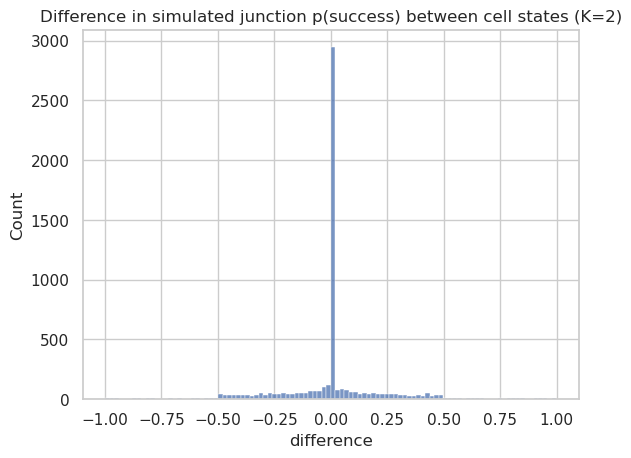

In [29]:
# plot histogram of difference
sns.histplot(cluster_labels["difference"], bins=100)
# add a title called "Difference in simulated junction p(success) between cell states (K=2)"
plt.title("Difference in simulated junction p(success) between cell states (K=2)")

In [30]:
# reclassify postive as negatives if differnces is close to 0 

In [31]:
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.head()

,0,1,new_junction_id_index,sample_label,Cluster,difference,true_label
0,0.450585,0.422694,0,positive,7,-0.027891,negative
2,0.450585,0.422694,1,positive,7,-0.027891,negative
0,0.335422,0.081455,2,positive,8,-0.253967,positive
2,0.335422,0.081455,3,positive,8,-0.253967,positive
0,0.253225,0.253225,4,negative,14,0.000000,negative


Text(0.5, 1.0, 'Observed junction usage ratios')

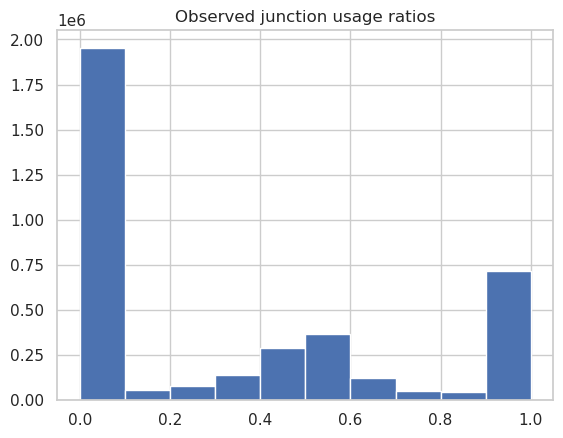

In [32]:
junc_ratios = final_data.juncratio
junc_ratios.hist()
# add title that says these are the observed junction usage ratios 
plt.title("Observed junction usage ratios")

In [33]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,27.0,1
1,0,1,37.0,1
2,0,2,11.0,1
3,0,3,8.0,1
4,0,4,12.0,1


In [34]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,new_junction_id_index,new_junc_count,new_cell_type
0,0,4,33.0,80,47.0,0.412500,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0,27.0,1
1,5176,4,29.0,78,49.0,0.371795,N2-MAA000572-3_8_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,34.0,0
2,5170,4,40.0,112,72.0,0.357143,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,47.0,0
3,5169,4,51.0,140,89.0,0.364286,N2-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,62.0,0
4,5162,4,67.0,169,102.0,0.396450,N19-MAA000590-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,68.0,0


### Prep simulated data as input into mixture model

In [35]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type
0,0,80,47.0,0.412500,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0,27.0,1
1,5176,78,49.0,0.371795,N2-MAA000572-3_8_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,34.0,0
2,5170,112,72.0,0.357143,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,47.0,0
3,5169,140,89.0,0.364286,N2-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,62.0,0
4,5162,169,102.0,0.396450,N19-MAA000590-3_9_M-1-1_Brain_Myeloid_microgli...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,68.0,0


In [36]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

Text(0.5, 1.0, 'Simulated junction usage ratios')

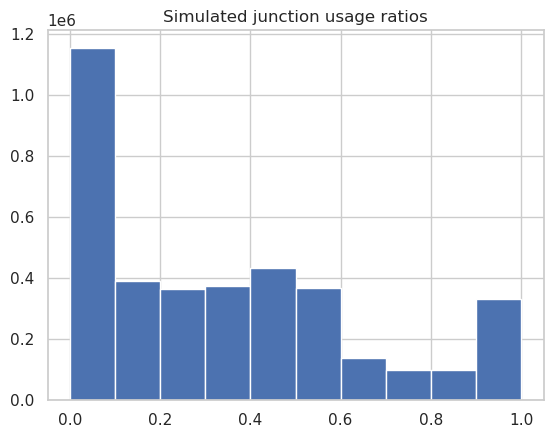

In [37]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]
sim_data.junc_ratio.hist()
# add title saying these are observed junction usage ratios
plt.title("Simulated junction usage ratios")

In [38]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
5968
5968


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


### Check how well the data is simulated, is there cell type specific splicing?

In [39]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()

In [40]:
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,7,Brain_Non-Myeloid_oligodendrocyte,0,0.375000,27.0,72.0,positive
1,0,7,Brain_Non-Myeloid_oligodendrocyte,1,0.513889,37.0,72.0,positive
2,0,7,Brain_Non-Myeloid_oligodendrocyte,2770,0.111111,8.0,72.0,positive
3,5176,7,Brain_Myeloid_microglial_cell,0,0.430380,34.0,79.0,positive
4,5176,7,Brain_Myeloid_microglial_cell,1,0.468354,37.0,79.0,positive


In [41]:
simple_data.Cluster.unique()

array([    7,     8,    14, ...,  2587, 15838,  5008])

Brain_Myeloid_microglial_cell        7950
Brain_Non-Myeloid_oligodendrocyte    3147
Name: cell_type, dtype: int64


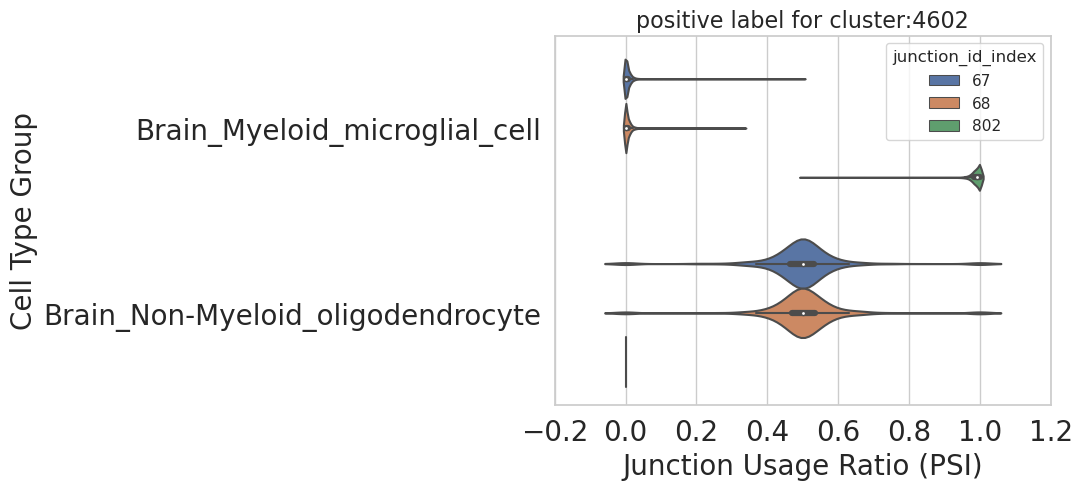

In [42]:
# let's visualize junction usage ratios for a given custer 
clust = 4602
quick_clust_plot(clust, simple_data)

Brain_Myeloid_microglial_cell        1950
Brain_Non-Myeloid_oligodendrocyte    1908
Name: cell_type, dtype: int64


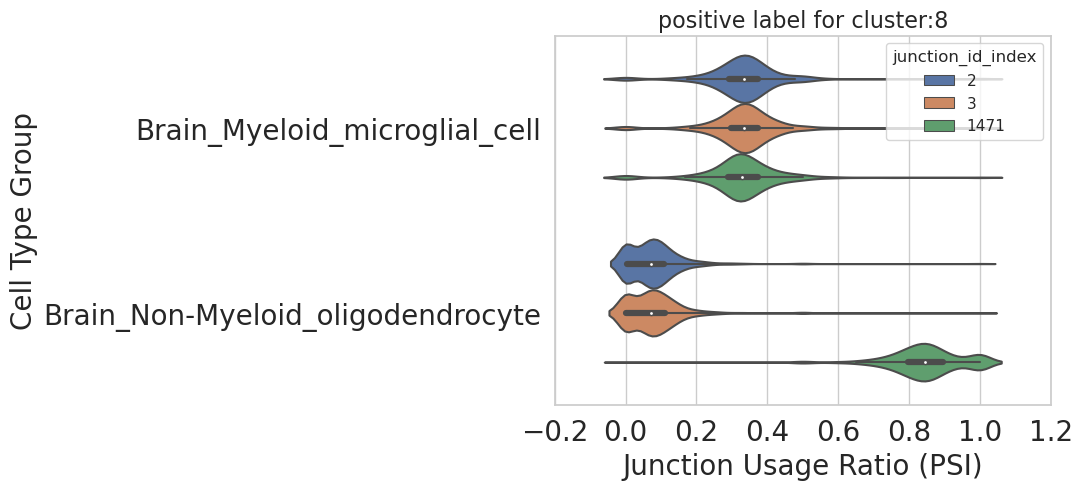

In [43]:
# let's visualize junction usage ratios for a given custer 
clust =8
quick_clust_plot(clust, simple_data)

### Run mixture model

In [44]:
K = 2
print(K)

2


In [45]:
# make new cell_ids_conversion dataframe using new cell type column
cell_ids_conversion_new = sim_data[["cell_id_index", "cell_type", "cell_id", "new_cell_type"]].drop_duplicates()
cell_ids_conversion_new.head()

,cell_id_index,cell_type,cell_id,new_cell_type
0,0,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1
3,5176,Brain_Myeloid_microglial_cell,N2-MAA000572-3_8_M-1-1_Brain_Myeloid_microglia...,0
6,5170,Brain_Myeloid_microglial_cell,N2-B001176-3_56_F-1-1_Brain_Myeloid_microglial...,0
9,5169,Brain_Myeloid_microglial_cell,N2-B000826-3_39_F-1-1_Brain_Myeloid_microglial...,0
12,5162,Brain_Myeloid_microglial_cell,N19-MAA000590-3_9_M-1-1_Brain_Myeloid_microgli...,0


In [46]:
# set random seed
torch.manual_seed(0)

num_trials = 50 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 5968 cells and J = 5676 junctions
Got the initial ELBO ^
ELBO converged @ -83897696.0 CAVI iteration # 5 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5968 cells and J = 5676 junctions
Got the initial ELBO ^
ELBO converged @ -83897704.0 CAVI iteration # 5 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5968 cells and J = 5676 junctions
Got the initial ELBO ^
ELBO converged @ -83897704.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5968 cells and J = 5676 junctions
Got the initial ELBO ^
ELBO converged @ -83897704.0 CAVI iteration # 4 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5968 cells and J = 5676 junctions
Got the initial ELBO ^
ELBO converged @ -83897696.0 CAVI iteration # 6 complete
Finished CAVI!
Initialize VI params
Init

The trial with the highest ELBO was 0


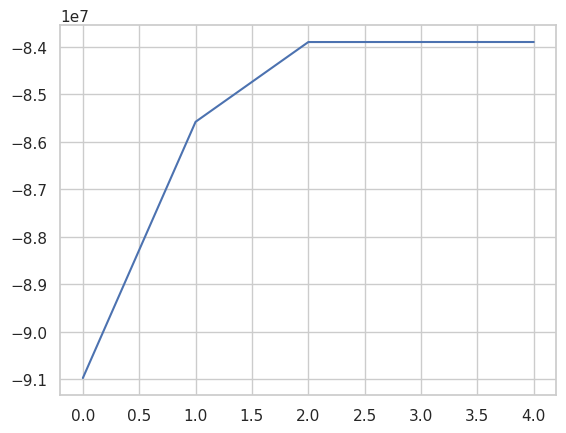

In [47]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

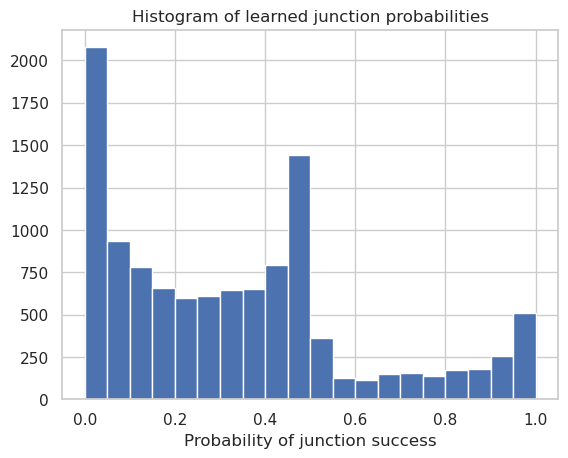

In [48]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

In [49]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()
# count number of times each cell type is assigned to each cell state
PHI_f_plot.groupby("cell_id").sum()

,0,1
cell_id,,
Brain_Myeloid_microglial_cell,4394.000000,2.202810e-08
Brain_Non-Myeloid_oligodendrocyte,0.194219,1.573806e+03


In [50]:
cell_ids_conversion_new.sort_values(by = ["cell_id_index"], inplace = True)
cell_ids_conversion_new.head()
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion_new['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
cell_types = cell_ids_conversion_new.new_cell_type.values
# Convert cell types to corresponding colors for rows and columns
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]
col_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

In [51]:
#all_iters_results = check_cell_pairs(results, row_colors, col_colors, cell_type_colors, num_cells_to_plot=100)

In [52]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [53]:
juncs_probs_df["learned_diff"] = juncs_probs_df["cell_state_1"] - juncs_probs_df["cell_state_0"]
cluster_labels.index = cluster_labels.new_junction_id_index.values
juncs_probs_df["sim_diff"] = cluster_labels["difference"]
juncs_probs_df["sample_label"] = cluster_labels["sample_label"]
juncs_probs_df["true_label"] = cluster_labels["true_label"]
juncs_probs_df["sample_label"] = cluster_labels["sample_label"]
juncs_probs_df.head()

,cell_state_0,cell_state_1,new_junction_id_index,junction_id,learned_diff,sim_diff,sample_label,true_label
0,0.450706,0.425075,0,1_5089111_5093362,-0.025631,-0.027891,positive,negative
1,0.449337,0.421446,1,1_5093452_5095614,-0.027891,-0.027891,positive,negative
2,0.335301,0.080005,2,1_5098133_5101069,-0.255296,-0.253967,positive,positive
3,0.335868,0.080591,3,1_5101123_5117389,-0.255278,-0.253967,positive,positive
4,0.256380,0.246622,4,1_7089216_7120193,-0.009758,0.000000,negative,negative


In [54]:
juncs_probs_df.sort_values(by = ["learned_diff"], inplace = True)
juncs_probs_df.head()

,cell_state_0,cell_state_1,new_junction_id_index,junction_id,learned_diff,sim_diff,sample_label,true_label
1390,0.997483,0.000119,1390,14_46814988_46815597,-0.997364,-0.997407,positive,positive
3117,0.996923,0.002091,3117,14_33390313_33392941,-0.994833,-0.998494,positive,positive
1817,0.999729,0.011230,1817,7_81788576_81789354,-0.988499,-0.989800,positive,positive
802,0.987922,0.000010,802,4_129842762_129846464,-0.987912,-0.987861,positive,positive
4311,0.996099,0.010697,4311,4_109056648_109058581,-0.985402,-0.984128,positive,positive


In [55]:
# get spearman correlation between learned and simulated differences
from scipy.stats import spearmanr
spearmanr(juncs_probs_df["learned_diff"], juncs_probs_df["sim_diff"])

SignificanceResult(statistic=0.9102633208273422, pvalue=0.0)

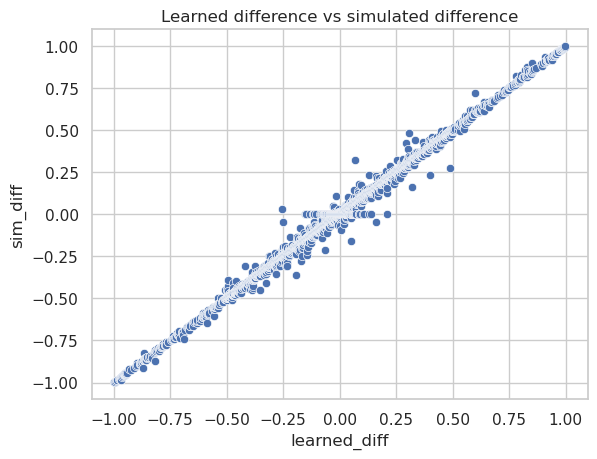

<Axes: xlabel='learned_diff', ylabel='sim_diff'>

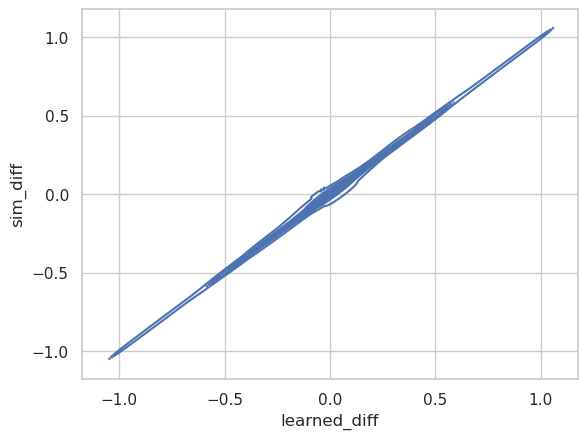

In [56]:
# plot correlation between learned and simulated difference
sns.scatterplot(data = juncs_probs_df, x = "learned_diff", y = "sim_diff")
plt.title("Learned difference vs simulated difference")
plt.show()
# show density where most points lie
sns.kdeplot(data = juncs_probs_df, x = "learned_diff", y = "sim_diff")

In [57]:
scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["new_junction_id_index"] = junction_ids_conversion.new_junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test = scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).new_junction_id_index.values

In [58]:
scores_all_juncs_df["sim_diff"] = cell_type_psi_df["difference"].values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,new_junction_id_index,sim_diff
802,217681.93750,802,-0.987861
2558,147045.75000,2558,-0.731962
330,138012.25000,330,0.812624
3237,127994.03125,3237,-0.913905
4205,121307.93750,4205,0.972137
3951,96212.56250,3951,0.954978
90,89142.37500,90,0.829028
4708,82014.31250,4708,0.830332
67,78312.75000,67,0.493930
68,77978.50000,68,0.493930


In [59]:
junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == 152]

,junction_id_index,junction_id,Cluster,new_junction_id_index
152,2008,6_4689767_4691428,7479,152


Brain_Myeloid_microglial_cell        4164
Brain_Non-Myeloid_oligodendrocyte    2283
Name: cell_type, dtype: int64


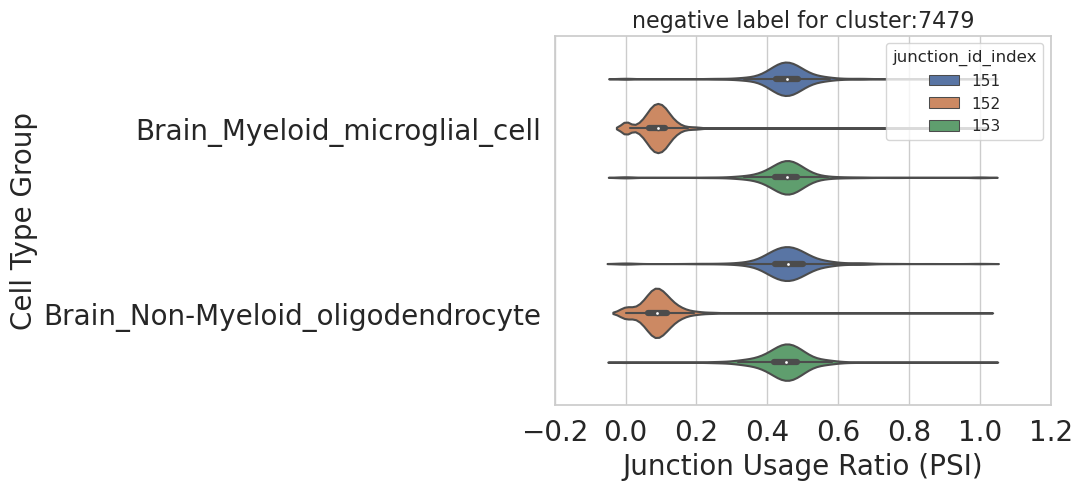

In [60]:
quick_clust_plot(7479, simple_data)

In [61]:
# for each junction get total sum of junc_count and also report gene_id 
sum_junc_counts = sim_data.groupby(["junction_id_index"]).agg({"junc_count": "sum"}).reset_index()
sum_junc_counts.sort_values(by = ["junction_id_index"], ascending = True, inplace = True)

In [62]:
sum_junc_counts["difference"] = cell_type_psi_df.difference.values

In [63]:
sum_junc_counts["score"] = scores_all_juncs_df["score"]
sum_junc_counts.head()

,junction_id_index,junc_count,difference,score
0,0,32453.0,-0.027891,20.906250
1,1,32281.0,-0.027891,25.343750
2,2,15465.0,-0.253967,3533.875000
3,3,15505.0,-0.253967,3524.968750
4,4,5826.0,0.000000,-1.101562


In [64]:
sim_data["new_cell_type"] = sim_data["new_cell_type"].astype(str)

Brain_Myeloid_microglial_cell        7950
Brain_Non-Myeloid_oligodendrocyte    3147
Name: cell_type, dtype: int64


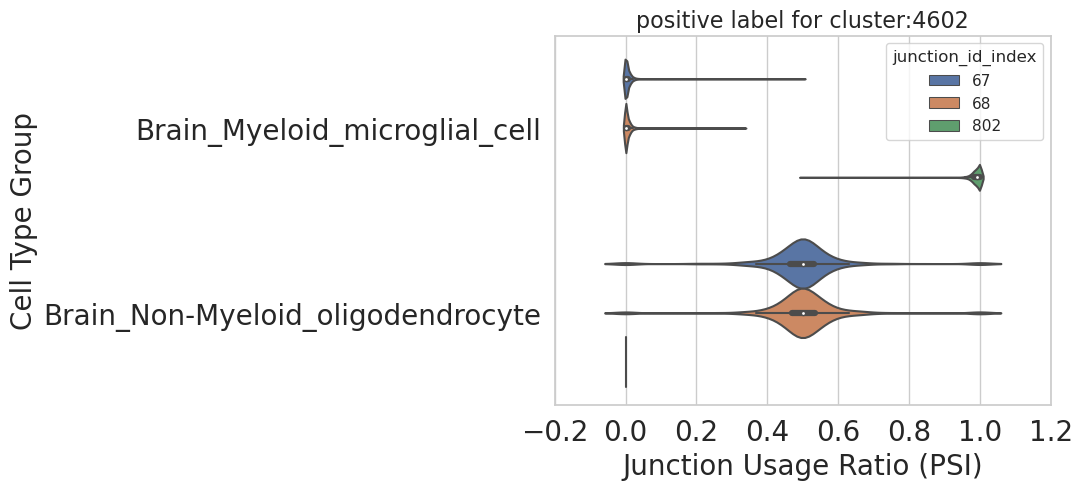

In [65]:
quick_clust_plot(4602, simple_data)

     junction_id_index            junction_id  Cluster  new_junction_id_index
802               7655  4_129842762_129846464     4602                    802


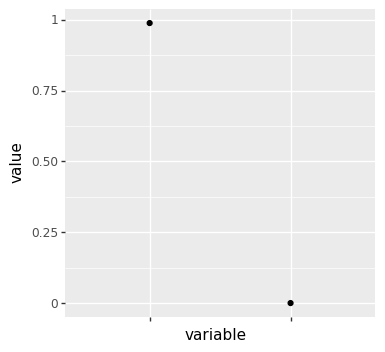


      junction_id_index            junction_id  Cluster  new_junction_id_index
2558              21427  7_126777953_126778305     8651                   2558


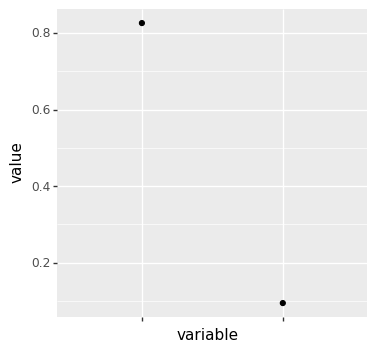

In [66]:
# for each junction in top10juncs_state1, run plot_juncObsUsage and plot_juncProbs
for junc in juncs_test:
    plot_juncProbs(junc)

In [67]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion_new.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion_new.new_cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_13175/4122663987.py:7: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_0,CellState_1
cell_type,,
0,4394.000000,2.202810e-08
1,0.194219,1.573806e+03


/scratch/ipykernel_13175/1592633849.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_13175/1592633849.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


<Axes: ylabel='cell_type'>

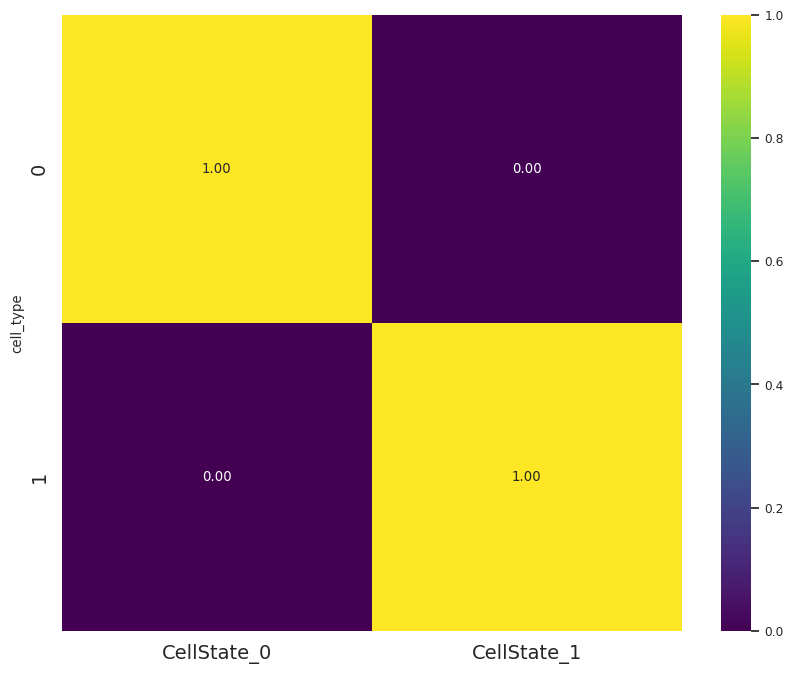

In [68]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(10, 8))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
sns.heatmap(sum_prop, annot=True, fmt=".2f", cmap='viridis')

In [69]:
scores_all_juncs_df["sample_label"] = cell_type_psi_df["sample_label"].values

In [70]:
# evaluate how well junctions are assigned to positive labels (associated with cell state) or negative (no association with cell state)
scores_all_juncs_df.sort_values(by="new_junction_id_index", inplace = True)
# add true_label column to scores_all_juncs_df
scores_all_juncs_df["true_label"] = cell_type_psi_df["true_label"].values
scores_all_juncs_df.head()

,score,new_junction_id_index,sim_diff,sample_label,true_label
0,20.906250,0,-0.027891,positive,negative
1,25.343750,1,-0.027891,positive,negative
2,3533.875000,2,-0.253967,positive,positive
3,3524.968750,3,-0.253967,positive,positive
4,-1.101562,4,0.000000,negative,negative


In [71]:
from scipy.special import logit, expit
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc

In [72]:
# make new column where label positive is 1 and negative is 0 in scores_all_juncs_df
scores_all_juncs_df["true_label_num"] = np.where(scores_all_juncs_df["sample_label"] == "positive", 1, 0)
scores_all_juncs_df.head()

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num
0,20.906250,0,-0.027891,positive,negative,1
1,25.343750,1,-0.027891,positive,negative,1
2,3533.875000,2,-0.253967,positive,positive,1
3,3524.968750,3,-0.253967,positive,positive,1
4,-1.101562,4,0.000000,negative,negative,0


In [73]:
scores_all_juncs_df

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num
0,20.906250,0,-0.027891,positive,negative,1
1,25.343750,1,-0.027891,positive,negative,1
2,3533.875000,2,-0.253967,positive,positive,1
3,3524.968750,3,-0.253967,positive,positive,1
4,-1.101562,4,0.000000,negative,negative,0
...,...,...,...,...,...,...
5671,-1.391357,5671,0.000000,negative,negative,0
5672,191.830566,5672,0.281599,positive,positive,1
5673,71.911133,5673,-0.140799,positive,negative,1
5674,-0.982910,5674,0.000000,negative,negative,0


In [74]:
cell_type_psi_df.index = cell_type_psi_df.new_junction_id_index.values
cell_type_psi_df

,0,1,new_junction_id_index,sample_label,Cluster,difference,true_label
0,0.450585,0.422694,0,positive,7,-0.027891,negative
1,0.450585,0.422694,1,positive,7,-0.027891,negative
2,0.335422,0.081455,2,positive,8,-0.253967,positive
3,0.335422,0.081455,3,positive,8,-0.253967,positive
4,0.253225,0.253225,4,negative,14,0.000000,negative
...,...,...,...,...,...,...,...
5671,0.280429,0.280429,5671,negative,6713,0.000000,negative
5672,0.540246,0.821845,5672,positive,8437,0.281599,positive
5673,0.229877,0.089078,5673,positive,8437,-0.140799,negative
5674,0.216347,0.216347,5674,negative,6136,0.000000,negative


SignificanceResult(statistic=0.8756731919207456, pvalue=0.0)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log


<Axes: xlabel='score', ylabel='difference'>

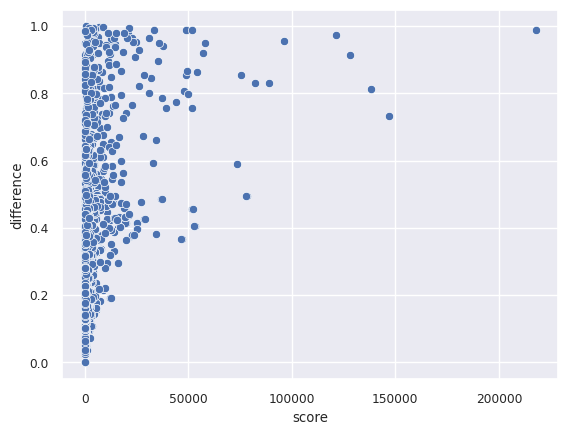

In [75]:
# get spearman correlation between score and simulated PSI difference
from scipy.stats import spearmanr
scores_all_juncs_df["difference"] =  cell_type_psi_df["difference"]
# get absolute value of difference
scores_all_juncs_df["difference"] = abs(scores_all_juncs_df["difference"])
# log transform score and add a small value to it 
scores_all_juncs_df["log_score"] = np.log(scores_all_juncs_df["score"] + 1e-10)
print(spearmanr(scores_all_juncs_df["score"], scores_all_juncs_df["difference"]))
# plot scatterplot of score vs difference
sns.scatterplot(data = scores_all_juncs_df, x = "score", y = "difference")

In [76]:
# run get_cluster_PSI on each cluster in clusters_SS
clusters_SS = sim_data["Cluster"].unique()
cluster_PSI = []
for cluster in tqdm(clusters_SS):
    cluster_PSI.append(get_cluster_PSI(cluster, sim_data, junc_info))

# convert cluster_PSI to dataframe
cluster_PSI = pd.concat(cluster_PSI)

  0%|          | 0/1892 [00:00<?, ?it/s]/scratch/ipykernel_13175/406269425.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/scratch/ipykernel_13175/406269425.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/scratch/ipykernel_13175/406269425.py:29: RuntimeWarning: invalid value encountered in float_scalars
  0%|          | 1/1892 [00:00<13:23,  2.35it/s]/scratch/ipykernel_13175/406269425.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [77]:
# convert cluster_PSI into wide matrix where the order of cell_id_index and Cluster in rows is the same as psix input for gene counts above 
cluster_PSI_wide = cluster_PSI.pivot(index = "Cluster", columns = "cell_id_index", values = "cluster_psi")
# remove cell_id_index and Cluster names 
cluster_PSI_wide.index.name = None
cluster_PSI_wide.columns.name = None
cluster_PSI_wide.head()

,0,1,2,3,4,5,6,7,8,9,...,5958,5959,5960,5961,5962,5963,5964,5965,5966,5967
7,0.111111,NaN,NaN,NaN,0.157895,NaN,0.100000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN
8,0.811881,NaN,NaN,NaN,0.796512,NaN,0.882353,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.230769,NaN,NaN,NaN,NaN
14,0.568627,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,0.888889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
sim_data[(sim_data["Cluster"] == 8) & (sim_data["cell_id_index"] == 4)]

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio
6426,4,306.0,0.444099,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5098133_5101069,8,2,38.0,1,344.0,0.110465
6427,4,312.0,0.555901,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5101123_5117389,8,3,32.0,1,344.0,0.093023
6428,4,70.0,0.000000,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5098133_5117389,8,1471,274.0,1,344.0,0.796512


In [79]:
# confirm that columns are exactly the same as gene_counts_df
print((cluster_PSI_wide.columns == gene_counts_df.columns).all())
print((cluster_PSI_wide.index == gene_counts_df.index).all())

True
True


In [80]:
gene_counts_df = gene_counts_df.T

In [81]:
# write cluster_PSI_wide to smae directory as gene_counts_df
cluster_PSI_wide.to_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/Simulations/Psix/Leaflet_generated_sim/cluster_PSI_wide.tsv.gz", sep="\t", compression="gzip")

In [82]:
sim_data.sort_values(by = ["cluster_count"], inplace = True, ascending = False)
scores_all_juncs_df.sort_values(by = ["score"], ascending = False).head(10)

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score
802,217681.93750,802,-0.987861,positive,positive,1,0.987861,12.290790
2558,147045.75000,2558,-0.731962,positive,positive,1,0.731962,11.898499
330,138012.25000,330,0.812624,positive,positive,1,0.812624,11.835098
3237,127994.03125,3237,-0.913905,positive,positive,1,0.913905,11.759739
4205,121307.93750,4205,0.972137,positive,positive,1,0.972137,11.706088
3951,96212.56250,3951,0.954978,positive,positive,1,0.954978,11.474315
90,89142.37500,90,0.829028,positive,positive,1,0.829028,11.397990
4708,82014.31250,4708,0.830332,positive,positive,1,0.830332,11.314649
67,78312.75000,67,0.493930,positive,positive,1,0.493930,11.268466
68,77978.50000,68,0.493930,positive,positive,1,0.493930,11.264188


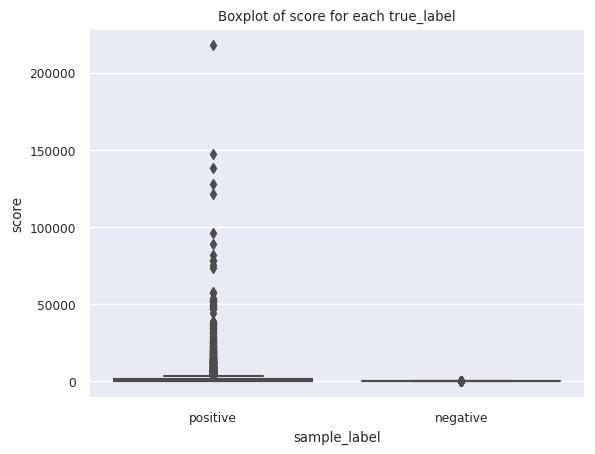

In [83]:
# make boxplot of score for each true_label
sns.boxplot(data = scores_all_juncs_df, x = "sample_label", y = "score")
plt.title("Boxplot of score for each true_label")
plt.show()

In [84]:
# sort first by true_label and then by score
scores_all_juncs_df.sort_values(by = ["true_label", "score"], ascending = False, inplace = True)
scores_all_juncs_df[scores_all_juncs_df["sample_label"] == "negative"].head(5)

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score
2166,8.850586,2166,0.0,negative,negative,0,0.0,2.180484
3308,6.889427,3308,0.0,negative,negative,0,0.0,1.929988
3374,6.385521,3374,0.0,negative,negative,0,0.0,1.854033
3355,5.029785,3355,0.0,negative,negative,0,0.0,1.615377
5588,4.336914,5588,0.0,negative,negative,0,0.0,1.467163


In [85]:
scores_all_juncs_df["q_value"] = 1 / scores_all_juncs_df["score"]
scores_all_juncs_df.sort_values(by = ["true_label", "q_value"], ascending = False, inplace = True)
scores_all_juncs_df.head()

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score,q_value
2270,0.396912,2270,-0.211756,positive,positive,1,0.211756,-0.924042,2.519453
5005,0.581062,5005,0.323456,positive,positive,1,0.323456,-0.542897,1.720986
3135,0.718750,3135,-0.279190,positive,positive,1,0.279190,-0.330242,1.391304
5299,0.940826,5299,0.234679,positive,positive,1,0.234679,-0.060997,1.062895
4120,1.554688,4120,-0.359546,positive,positive,1,0.359546,0.441275,0.643216


In [86]:
print(scores_all_juncs_df[scores_all_juncs_df["sample_label"] == "positive"].shape)
print(scores_all_juncs_df[scores_all_juncs_df["sample_label"] == "negative"].shape)

(2844, 9)
(2832, 9)


<Axes: >

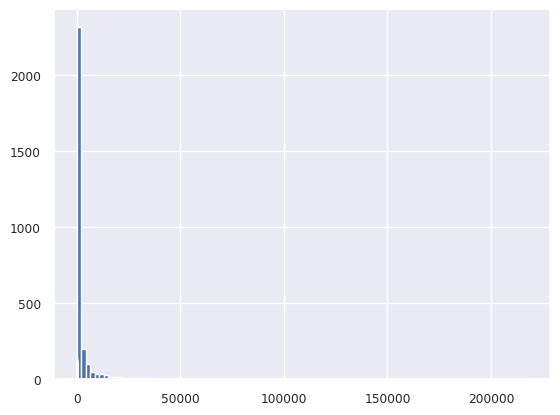

In [87]:
scores_all_juncs_df[(scores_all_juncs_df["sample_label"] == "positive")].score.hist(bins=100)
scores_all_juncs_df[(scores_all_juncs_df["sample_label"] == "negative")].score.hist(bins=100)

In [88]:
scores_all_juncs_df.sort_values(by = "score", ascending = False).head(10)

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score,q_value
802,217681.93750,802,-0.987861,positive,positive,1,0.987861,12.290790,0.000005
2558,147045.75000,2558,-0.731962,positive,positive,1,0.731962,11.898499,0.000007
330,138012.25000,330,0.812624,positive,positive,1,0.812624,11.835098,0.000007
3237,127994.03125,3237,-0.913905,positive,positive,1,0.913905,11.759739,0.000008
4205,121307.93750,4205,0.972137,positive,positive,1,0.972137,11.706088,0.000008
3951,96212.56250,3951,0.954978,positive,positive,1,0.954978,11.474315,0.000010
90,89142.37500,90,0.829028,positive,positive,1,0.829028,11.397990,0.000011
4708,82014.31250,4708,0.830332,positive,positive,1,0.830332,11.314649,0.000012
67,78312.75000,67,0.493930,positive,positive,1,0.493930,11.268466,0.000013
68,77978.50000,68,0.493930,positive,positive,1,0.493930,11.264188,0.000013


In [89]:
junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == 802]

,junction_id_index,junction_id,Cluster,new_junction_id_index
802,7655,4_129842762_129846464,4602,802


Brain_Myeloid_microglial_cell        4164
Brain_Non-Myeloid_oligodendrocyte    2283
Name: cell_type, dtype: int64


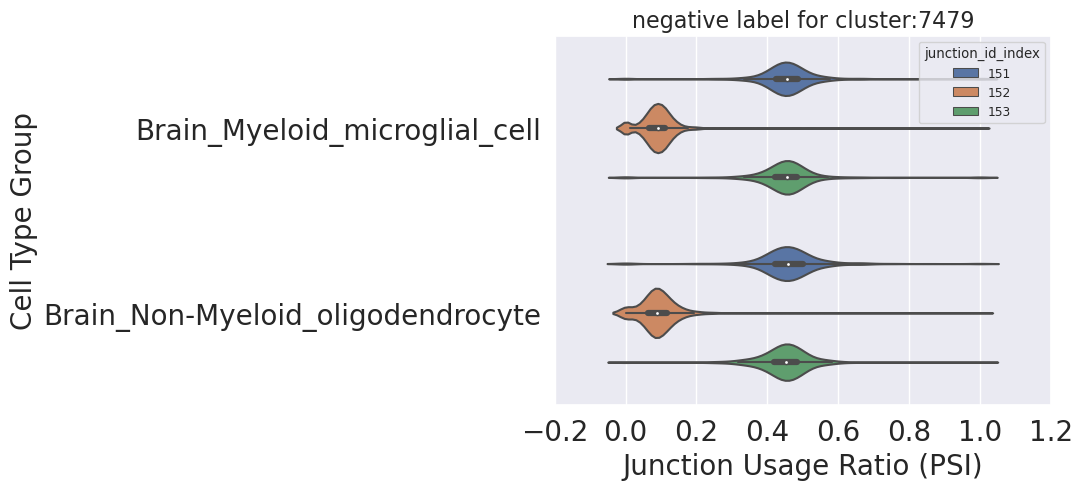

In [90]:
quick_clust_plot(7479, simple_data)

Brain_Myeloid_microglial_cell        7950
Brain_Non-Myeloid_oligodendrocyte    3147
Name: cell_type, dtype: int64


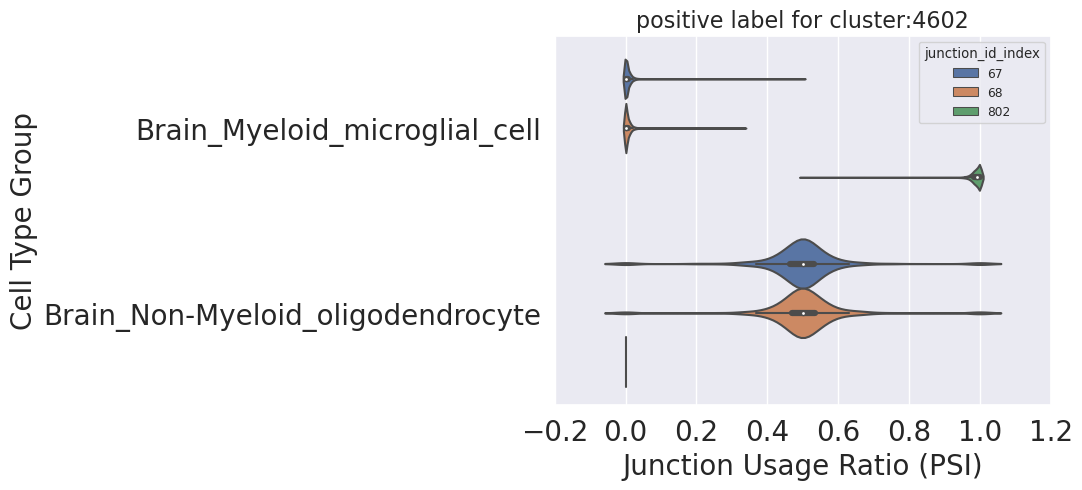

In [91]:
quick_clust_plot(4602, simple_data)

In [92]:
# what if we assessed performance on the cluster level - combine junction scores in each cluster by summing them up 
clust_level_scores = scores_all_juncs_df.merge(junction_ids_conversion, on = ["new_junction_id_index"])

# for each cluster, sum up the scores for its three junctions to get one score per cluster and also keep sample_label 
clust_level_scores = clust_level_scores.groupby(["Cluster", "sample_label", "true_label_num"]).agg({"score": "sum"}).reset_index()
clust_level_scores.head()

,Cluster,sample_label,true_label_num,score
0,7,positive,1,280.718750
1,8,positive,1,16724.593750
2,14,negative,0,-5.726562
3,17,positive,1,722.757812
4,21,negative,0,-5.974609


In [93]:
pre, rec, thres = precision_recall_curve(clust_level_scores["true_label_num"], clust_level_scores["score"])

# Calculate AUC-ROC
auc_roc = roc_auc_score(clust_level_scores["true_label_num"], clust_level_scores["score"])
print("The AUC ROC is: " + str(auc_roc))

auc_pr = auc(rec, pre)
print("the AUC_PR is: " + str(auc_pr))

The AUC ROC is: 0.9853130810627189
the AUC_PR is: 0.9892877373403988


The AUC ROC is: 0.9744886151437857
the AUC_PR is: 0.9819603497058194


Text(0, 0.5, 'Precision')

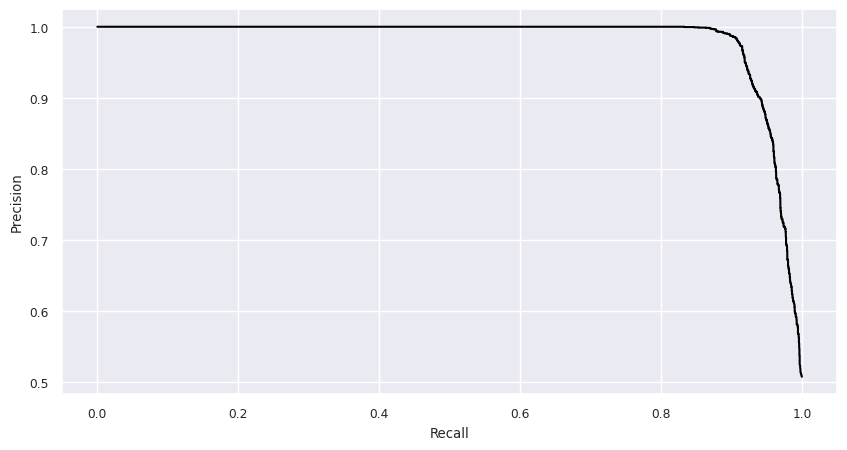

In [94]:
pre, rec, thres = precision_recall_curve(scores_all_juncs_df["true_label_num"], scores_all_juncs_df["score"])

# Calculate AUC-ROC
auc_roc = roc_auc_score(scores_all_juncs_df["true_label_num"], scores_all_juncs_df["score"])
print("The AUC ROC is: " + str(auc_roc))

auc_pr = auc(rec, pre)
print("the AUC_PR is: " + str(auc_pr))

# plot precision recall curve using values calculated above
plt.figure(figsize=(10, 5))
plt.plot(rec, pre, color='black')
plt.xlabel('Recall')
plt.ylabel('Precision')

In [95]:
print(len(sim_data.cell_id_index.unique()))
len(sim_data.Cluster.unique())

5968


1892

In [96]:
len(scores_all_juncs_df.new_junction_id_index.unique())

5676

In [97]:
scores_all_juncs_df.sort_values(by = ["score"], ascending = False, inplace = True)
scores_all_juncs_df.head(10)

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score,q_value
802,217681.93750,802,-0.987861,positive,positive,1,0.987861,12.290790,0.000005
2558,147045.75000,2558,-0.731962,positive,positive,1,0.731962,11.898499,0.000007
330,138012.25000,330,0.812624,positive,positive,1,0.812624,11.835098,0.000007
3237,127994.03125,3237,-0.913905,positive,positive,1,0.913905,11.759739,0.000008
4205,121307.93750,4205,0.972137,positive,positive,1,0.972137,11.706088,0.000008
3951,96212.56250,3951,0.954978,positive,positive,1,0.954978,11.474315,0.000010
90,89142.37500,90,0.829028,positive,positive,1,0.829028,11.397990,0.000011
4708,82014.31250,4708,0.830332,positive,positive,1,0.830332,11.314649,0.000012
67,78312.75000,67,0.493930,positive,positive,1,0.493930,11.268466,0.000013
68,77978.50000,68,0.493930,positive,positive,1,0.493930,11.264188,0.000013


In [98]:
scores_all_juncs_df.sort_values(by = ["score"], ascending = True, inplace = True)
scores_all_juncs_df.head(2)

,score,new_junction_id_index,sim_diff,sample_label,true_label,true_label_num,difference,log_score,q_value
629,-4.2500,629,0.0,negative,negative,0,0.0,NaN,-0.235294
209,-4.0625,209,0.0,negative,negative,0,0.0,NaN,-0.246154


In [99]:
print("the number of cells in the simulated data is {}".format(len(cluster_PSI.cell_id_index.unique())))
print("the number of clusters in the simulated data is {}".format(len(cluster_PSI.Cluster.unique())))

the number of cells in the simulated data is 5968
the number of clusters in the simulated data is 1892


In [100]:
# remove rows from cluster_PSI that contain NaN in cluster_psi column
cluster_PSI.dropna(inplace = True)
# merge cluster_PSI with cell_ids_conversion_new to get cell_type
cluster_PSI = cluster_PSI.merge(cell_ids_conversion_new, on = ["cell_id_index"])
cluster_PSI.head()

,cell_id_index,Cluster,cluster_psi,cell_type,cell_id,new_cell_type
0,0,7,0.111111,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1
1,0,8,0.811881,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1
2,0,14,0.568627,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1
3,0,17,0.888889,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1
4,0,221,0.777778,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1


In [101]:
clustlabels = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
# merge clustlabels with cluster_PSI to get sample_label
cluster_PSI = cluster_PSI.merge(clustlabels, on = ["Cluster"])
cluster_PSI.head()

,cell_id_index,Cluster,cluster_psi,cell_type,cell_id,new_cell_type,sample_label
0,0,7,0.111111,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1,positive
1,4,7,0.157895,Brain_Non-Myeloid_oligodendrocyte,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,1,positive
2,6,7,0.100000,Brain_Non-Myeloid_oligodendrocyte,A10-MAA000944-3_9_M-1-1_Brain_Non-Myeloid_olig...,1,positive
3,10,7,0.149254,Brain_Non-Myeloid_oligodendrocyte,A11-MAA000930-3_8_M-1-1_Brain_Non-Myeloid_olig...,1,positive
4,17,7,0.500000,Brain_Non-Myeloid_oligodendrocyte,A13-MAA000563-3_10_M-1-1_Brain_Non-Myeloid_oli...,1,positive


In [102]:
sim_data[(sim_data["Cluster"] == 7) & (sim_data["cell_id_index"] == 4)]

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio
2892,4,205.0,0.335244,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0,156.0,1,361.0,0.432133
2894,4,304.0,0.000000,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5095614,7,2770,57.0,1,361.0,0.157895
2893,4,213.0,0.664756,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,Brain_Non-Myeloid_oligodendrocyte,1_5093452_5095614,7,1,148.0,1,361.0,0.409972


In [103]:
# get metrics using KW test 
from scipy.stats import kruskal
# for each cluster get KW statistic and p-value 
kw_stats = []
clusters_SS = cluster_PSI["Cluster"].unique()

for clust in tqdm(clusters_SS):
    clust_dat = cluster_PSI[cluster_PSI["Cluster"] == clust]
    # get cluster_psi for each cell in clust_dat
    clust_psi = clust_dat["cluster_psi"].values
    # get cell_type for each cell in clust_dat
    clust_cell_type = clust_dat["new_cell_type"].values
    # run kruskal test on clust_psi and clust_cell_type
    kw_stat, kw_pval = kruskal(clust_psi, clust_cell_type)
    # save cluster, state and pvalue as well as label for positive or negative cluster 
    kw_stats.append([clust, kw_stat, kw_pval, clust_dat["sample_label"].values[0]])

100%|██████████| 1892/1892 [00:06<00:00, 291.68it/s]


In [104]:
# combine kw_stats into dataframe
kw_stats_df = pd.DataFrame(kw_stats, columns = ["Cluster", "kw_stat", "kw_pval", "sample_label"])

In [105]:
cluster_PSI.head()

,cell_id_index,Cluster,cluster_psi,cell_type,cell_id,new_cell_type,sample_label
0,0,7,0.111111,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1_Brain_Non-Myeloid_olig...,1,positive
1,4,7,0.157895,Brain_Non-Myeloid_oligodendrocyte,A10-MAA000935-3_8_M-1-1_Brain_Non-Myeloid_olig...,1,positive
2,6,7,0.100000,Brain_Non-Myeloid_oligodendrocyte,A10-MAA000944-3_9_M-1-1_Brain_Non-Myeloid_olig...,1,positive
3,10,7,0.149254,Brain_Non-Myeloid_oligodendrocyte,A11-MAA000930-3_8_M-1-1_Brain_Non-Myeloid_olig...,1,positive
4,17,7,0.500000,Brain_Non-Myeloid_oligodendrocyte,A13-MAA000563-3_10_M-1-1_Brain_Non-Myeloid_oli...,1,positive


In [106]:
kw_stats_df.sort_values(by = ["kw_stat"], ascending = False).head(10)

,Cluster,kw_stat,kw_pval,sample_label
700,8310,7323.195792,0.0,negative
1844,21204,7234.824642,0.0,positive
1285,10830,6803.257584,0.0,negative
1866,14085,6701.541010,0.0,negative
1296,8402,6369.725559,0.0,negative
1859,494,5960.887347,0.0,negative
1880,16090,5461.730703,0.0,positive
1609,9183,5300.492075,0.0,positive
1864,12100,4825.020277,0.0,positive
183,12099,4747.231071,0.0,negative


Brain_Myeloid_microglial_cell        10803
Brain_Non-Myeloid_oligodendrocyte       54
Name: cell_type, dtype: int64


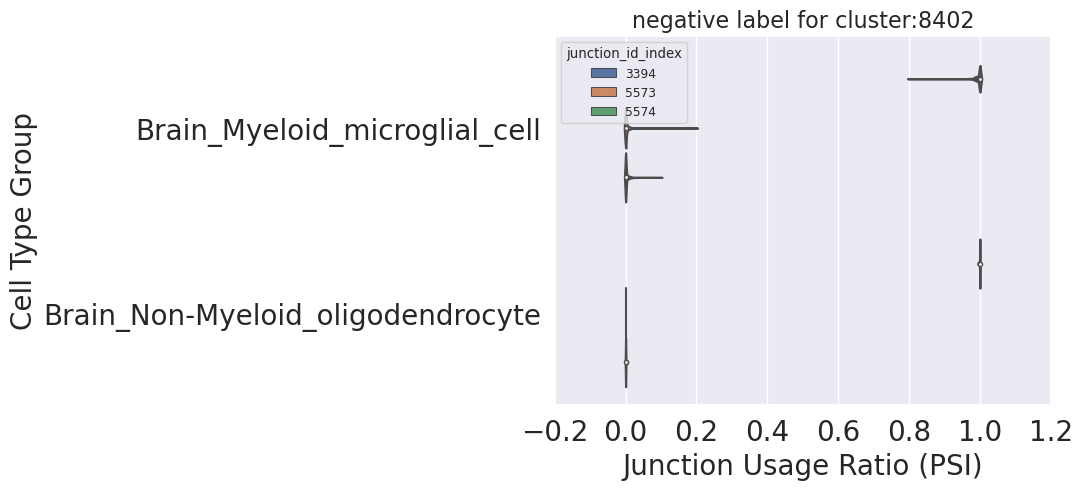

In [107]:
quick_clust_plot(8402, simple_data)

In [108]:
kw_stats_df["sample_label_num"] = np.where(kw_stats_df["sample_label"] == "positive", 1, 0)
kw_stats_df.head()

,Cluster,kw_stat,kw_pval,sample_label,sample_label_num
0,7,8.209951,4.166127e-03,positive,1
1,8,1.722963,1.893121e-01,positive,1
2,14,13.180758,2.828383e-04,negative,0
3,17,3.450548,6.323081e-02,positive,1
4,221,31.121676,2.423499e-08,negative,0


In [109]:
# calculate AUC ROC and AUC PR for kw_stats_df
# calculate precision recall AUC for ks_stats_df
pre, rec, thres = precision_recall_curve(kw_stats_df["sample_label_num"].values, kw_stats_df["kw_stat"].values)
auc_pr = auc(rec, pre)
print("the AUC_PR is: " + str(auc_pr))
# now calculate AUC 
auc_roc = roc_auc_score(kw_stats_df["sample_label_num"].values, kw_stats_df["kw_stat"].values)
print("The AUC ROC is: " + str(auc_roc))

the AUC_PR is: 0.48644146253728815
The AUC ROC is: 0.47378513194593436


Brain_Non-Myeloid_oligodendrocyte    3867
Brain_Myeloid_microglial_cell          18
Name: cell_type, dtype: int64


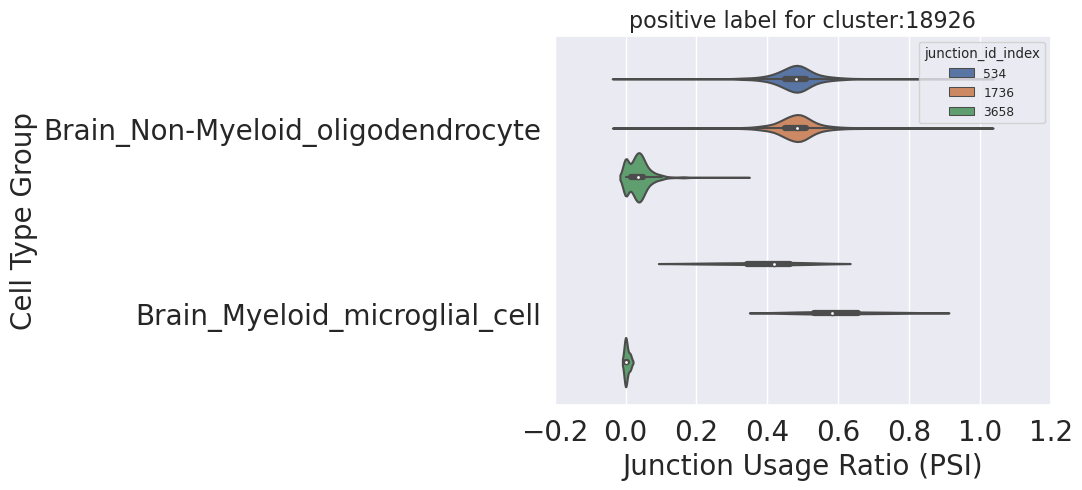

In [110]:
quick_clust_plot(18926, simple_data)

In [111]:
# for Kruskal Wallis test let's just compare the junction usage ratios 
def ks_test(junc, junc_labels):
    test = sim_data[sim_data["junction_id_index"]==junc]
    test.dropna(inplace = True)
    if len(test.junc_ratio.unique()) > 1:
        ks, pval = kruskal(test[test["new_cell_type"] == "0"]["junc_ratio"], test[test["new_cell_type"] == "1"]["junc_ratio"])
        # save junc, ks and pval as well as label for positive or negative cluster
        junc_label = junc_labels[junc_labels["junction_id_index"] == junc]["sample_label"].values[0]
        return([junc, ks, pval, junc_label])
    else:
        print("junction {} has only one junction usage ratio".format(junc))

In [112]:
junc_labels=cluster_labels[["new_junction_id_index", "sample_label", "Cluster"]].drop_duplicates()
# rename new_junction_id_index to junction_id_index
junc_labels.rename(columns = {"new_junction_id_index": "junction_id_index"}, inplace = True)
# merge junc_labels with sim_data to get sample_label
junc_labels = sim_data.merge(junc_labels, on = ["junction_id_index"])
junc_labels.head()

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster_x,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio,sample_label,Cluster_y
0,1065,4318.0,0.431018,K21-B003277-3_39_F-1-1_Brain_Non-Myeloid_oligo...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0,3091.0,1,7409.0,0.417195,positive,7
1,3522,690.0,0.381271,H9-MAA000571-3_9_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,550.0,0,1240.0,0.443548,positive,7
2,2490,419.0,0.433155,D22-B000826-3_39_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,340.0,0,759.0,0.447958,positive,7
3,2569,295.0,0.435424,D8-MAA000571-3_9_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,246.0,0,541.0,0.454713,positive,7
4,5089,252.0,0.443966,N15-B003278-3_38_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,219.0,0,471.0,0.464968,positive,7


In [113]:
junc_labels[junc_labels["sample_label"] == "positive"].head()

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster_x,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio,sample_label,Cluster_y
0,1065,4318.0,0.431018,K21-B003277-3_39_F-1-1_Brain_Non-Myeloid_oligo...,Brain_Non-Myeloid_oligodendrocyte,1_5089111_5093362,7,0,3091.0,1,7409.0,0.417195,positive,7
1,3522,690.0,0.381271,H9-MAA000571-3_9_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,550.0,0,1240.0,0.443548,positive,7
2,2490,419.0,0.433155,D22-B000826-3_39_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,340.0,0,759.0,0.447958,positive,7
3,2569,295.0,0.435424,D8-MAA000571-3_9_M-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,246.0,0,541.0,0.454713,positive,7
4,5089,252.0,0.443966,N15-B003278-3_38_F-1-1_Brain_Myeloid_microglia...,Brain_Myeloid_microglial_cell,1_5089111_5093362,7,0,219.0,0,471.0,0.464968,positive,7


In [114]:
# run for all junctions in sim_data
ks_stats = []
juncs_SS = sim_data["junction_id_index"].unique()
for junc in tqdm(juncs_SS):
    ks_stats.append(ks_test(junc, junc_labels))

  0%|          | 0/5676 [00:00<?, ?it/s]/scratch/ipykernel_13175/673189746.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 13%|█▎        | 759/5676 [00:11<01:13, 66.57it/s]

junction 1922 has only one junction usage ratio


 15%|█▌        | 862/5676 [00:13<01:06, 71.99it/s]

junction 5010 has only one junction usage ratio


 22%|██▏       | 1257/5676 [00:19<00:58, 75.40it/s]

...

 98%|█████████▊| 5559/5676 [01:18<00:01, 80.84it/s]

junction 5289 has only one junction usage ratio
junction 5288 has only one junction usage ratio
junction 5053 has only one junction usage ratio


 98%|█████████▊| 5578/5676 [01:18<00:01, 83.03it/s]

junction 3095 has only one junction usage ratio
junction 3905 has only one junction usage ratio
junction 3906 has only one junction usage ratio


100%|██████████| 5676/5676 [01:19<00:00, 71.35it/s]


In [115]:
# convert ks_stats to dictionary from ist 
ks_stats_dict = {}
for i in range(len(ks_stats)):
    ks_stats_dict[i] = ks_stats[i]
# convert ks_stats_dict to dataframe
ks_stats_df = pd.DataFrame.from_dict(ks_stats_dict)
ks_stats_df = ks_stats_df.T
# give them proper columns 
ks_stats_df.columns = ["junction_id_index", "ks_stat", "ks_pval", "sample_label"]
ks_stats_df.head()

,junction_id_index,ks_stat,ks_pval,sample_label
0,0,17.871313,0.000024,positive
1,1,40.371569,0.0,positive
2,2770,116.178857,0.0,positive
3,1471,918.384854,0.0,positive
4,3,793.515504,0.0,positive


In [116]:
# reorder ks_stats_df by junction_id_index
ks_stats_df.sort_values(by = ["junction_id_index"], inplace = True)
# convert sample_label to numeric
ks_stats_df["sample_label"] = np.where(ks_stats_df["sample_label"] == "positive", 1, 0)
ks_stats_df.head()

,junction_id_index,ks_stat,ks_pval,sample_label
0,0,17.871313,0.000024,1
1,1,40.371569,0.0,1
5,2,818.421969,0.0,1
4,3,793.515504,0.0,1
2083,4,0.339726,0.559988,0


In [117]:
# keep only rows where ks_stat is not None
ks_stats_df = ks_stats_df[ks_stats_df["ks_stat"].notnull()]

In [118]:
# calculate precision recall AUC for ks_stats_df
pre, rec, thres = precision_recall_curve(ks_stats_df["sample_label"].values, ks_stats_df["ks_stat"].values)
auc_pr = auc(rec, pre)
print("the AUC_PR is: " + str(auc_pr))
# now calculate AUC 
auc_roc = roc_auc_score(ks_stats_df["sample_label"].values, ks_stats_df["ks_stat"].values)
print("The AUC ROC is: " + str(auc_roc))

the AUC_PR is: 0.96346496827864
The AUC ROC is: 0.9463760783521281


The AUC ROC is: 0.47378513194593436
the AUC_PR is: 0.48644146253728815


Text(0, 0.5, 'Precision')

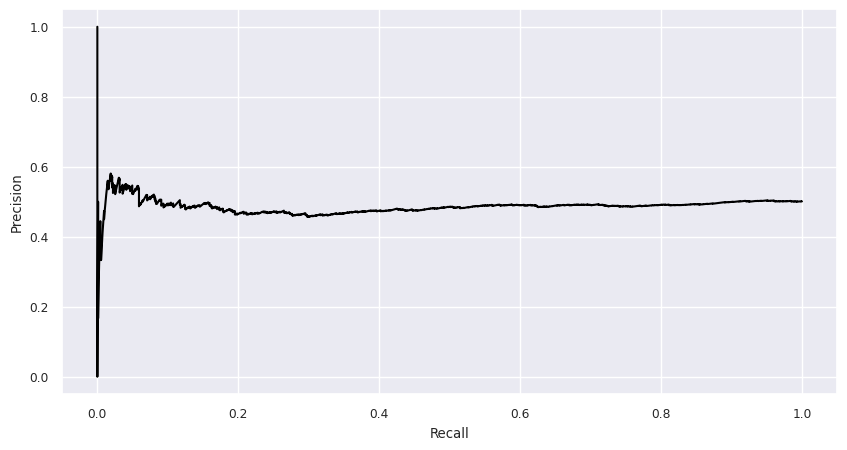

In [119]:
pre, rec, thres = precision_recall_curve(kw_stats_df["sample_label_num"], kw_stats_df["kw_stat"])

# Calculate AUC-ROC
auc_roc = roc_auc_score(kw_stats_df["sample_label_num"], kw_stats_df["kw_stat"])
print("The AUC ROC is: " + str(auc_roc))

auc_pr = auc(rec, pre)
print("the AUC_PR is: " + str(auc_pr))

# plot precision recall curve using values calculated above
plt.figure(figsize=(10, 5))
plt.plot(rec, pre, color='black')
plt.xlabel('Recall')
plt.ylabel('Precision')